<a href="https://colab.research.google.com/github/Rithvikns/python/blob/main/Framework/Pytorch/Project_3-GNN/GNN_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install torch torch_geometric networkx matplotlib numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [4]:
edges = torch.tensor([[0, 1, 2, 3], [1, 2, 3, 0]], dtype=torch.long)  # (source, target)
weights = torch.tensor([0.5, 0.8, 0.6, 0.9], dtype=torch.float)  # Edge weights
num_nodes = 4


In [5]:
# Node features (random dummy features)
node_features = torch.rand((num_nodes, 3))

# Create PyTorch Geometric Data Object
graph_data = Data(x=node_features, edge_index=edges, edge_attr=weights)


In [6]:
class SimpleGNN(torch.nn.Module):
    def __init__(self):
        super(SimpleGNN, self).__init__()
        self.conv1 = GCNConv(3, 16)  # Input: 3 features, Output: 16 features
        self.conv2 = GCNConv(16, 2)  # Output: 2 features (for example, binary classification)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

Node Features Output:
tensor([[0.1118, 0.3249],
        [0.1441, 0.2893],
        [0.0800, 0.2891],
        [0.0478, 0.3247]], grad_fn=<AddBackward0>)


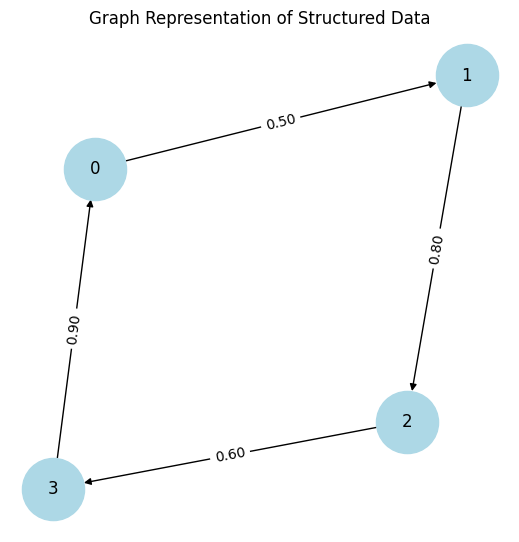

In [7]:
# Instantiate and forward pass
model = SimpleGNN()
output = model(graph_data)

print("Node Features Output:")
print(output)

# Visualizing the graph
G = nx.DiGraph()
for i in range(edges.shape[1]):
    G.add_edge(int(edges[0, i]), int(edges[1, i]), weight=weights[i].item())

plt.figure(figsize=(5, 5))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(int(edges[0, i]), int(edges[1, i])): f'{weights[i]:.2f}' for i in range(edges.shape[1])})
plt.title("Graph Representation of Structured Data")
plt.show()